In [26]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns

from pathlib import Path
from MITRotor import IEA10MW

In [27]:
rotor = IEA10MW()

nElements = 26
nSections = 158

In [28]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [29]:
# casenames = [r'new_c_ceoff/U06', r'new_c_ceoff/U07', r'new_c_ceoff/U08', r'new_c_ceoff/U09', r'new_c_ceoff/U10']
# casenames = [r'U06', r'U07', r'U08', r'U09', r'U10']

casenames = [r'old_case']

wrfles_bem = []
# wrfles_wind = []
for count, name in enumerate(casenames):
    wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/s000_v000/U07_lite.npz')))


In [30]:
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/s000_v000/input_sounding")

data = extract_columns(file_list)

t = np.linspace(0,2*np.pi,nSections)
r = np.linspace(0,1,nElements)

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles_bem[0]['diameter']/2 + 378

In [31]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [32]:
data

{'s000_v000': array([[  0.,   7.,   0.],
        [  1.,   7.,   0.],
        [  2.,   7.,   0.],
        ...,
        [829.,   7.,   0.],
        [830.,   7.,   0.],
        [831.,   7.,   0.]], shape=(832, 3))}

In [10]:
wrfles_bem[count]['shapiroM'][0]

array([0.9876935], dtype=float32)

/tmp/ipykernel_130729/542744678.py:71: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=110, edgecolor='none',color=colors[count],alpha=0.5,label = leg_strs[count], zorder = count + 2)


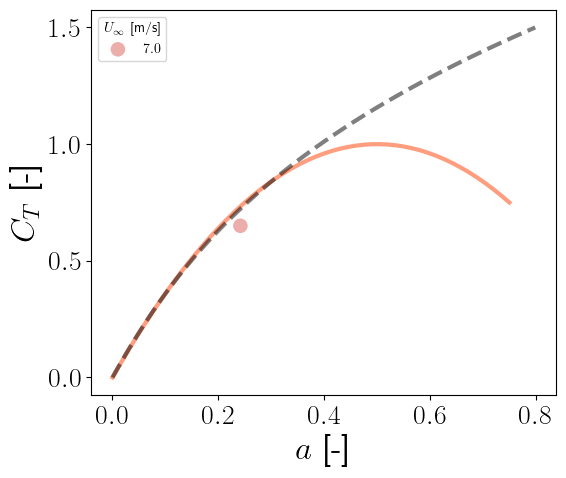

In [34]:
xs = [0,1,1,1,2,3,3,3,3,3,4,5,5,5,6]
ys = [2,1,2,3,2,0,1,2,3,4,2,1,2,3,2]

# leg_strs = ['$6.0$','$7.0$','$8.0$', '$9.0$', '$10.0$']
leg_strs = ['$7.0$']

ind_rotor = np.zeros_like(xs, dtype=float)
ct_rotor  = np.zeros_like(xs, dtype=float)

ind_loc = np.zeros((nElements, nSections, len(xs)))
ct_loc  = np.zeros((nElements, nSections, len(xs)))

colors = sns.color_palette("hls", 5)

fig, ax = plt.subplots(figsize=(6, 5))

casenames = ['s000_v000']

for count,case in enumerate(casenames):
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Get radial points
    # a = ((wrfles_bem[count]['rOverR'] * rotor.R) - rotor.hub_radius)/rotor.R
    # r = (rotor.hub_radius + a * (rotor.R - rotor.hub_radius)) / rotor.R

    r = wrfles_bem[count]['rOverR'] * rotor.R

    # Compute induction
    # ind = 1 - np.mean(wrfles_bem[count]['shapiroM'][0] * wrfles_bem[count]['u'],axis=0) / u_inf.T
    ind = 1 - np.mean(wrfles_bem[count]['u'],axis=0) / u_inf.T


    phi = np.deg2rad(np.mean(wrfles_bem[count]['phi'], axis=0))
    Cl = np.mean(wrfles_bem[count]['cl'], axis=0)
    Cd = np.mean(wrfles_bem[count]['cd'], axis=0)

    r =  (np.ones_like(Cd.T) * r).T

    # Solidity
    # sigma = rotor.solidity_func(r)

    chord = [4.667699,4.946444,5.225188,5.503933,5.782678,5.954899,5.91736,5.619165,5.320971,5.022776,4.724581,4.426386,4.128191,3.814344,3.49131,3.183023,2.91082,2.638617,2.34715,2.047023,1.746895,1.446768,1.146641,0.846513,0.546386,0.246259,]

    chord =  (np.ones_like(Cd.T) * chord).T

    sigma = (3 * chord) / (2 * np.pi * r)

    # Relative velocity
    W = np.mean(wrfles_bem[count]['vrel'], axis=0) / ((u_inf**2 + v_inf**2)**(1/2)).T

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    # ct = sigma * W**2 * Cax * wrfles_bem[count]['shapiroM'][0]**2
    ct = sigma * W**2 * Cax

    ind_loc[:,:,count] = ind
    ct_loc[:,:,count]  = ct

    ct_annular  = 1/(2 * np.pi) * np.trapezoid(ct, np.linspace(0, 2*np.pi, nSections), axis=-1)
    ind_annular = 1/(2 * np.pi) * np.trapezoid(ind, np.linspace(0, 2*np.pi, nSections), axis=-1)

    ct_rotor[count]  = 2 * np.trapezoid(ct_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])
    ind_rotor[count] = 2 * np.trapezoid(ind_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])

    ax.scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=110, edgecolor='none',color=colors[count],alpha=0.5,label = leg_strs[count], zorder = count + 2)

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,alpha = 0.5, zorder = 1)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,alpha=0.5,zorder=2)

ax.set_xlabel('$a$ [-]', fontsize=fontsize)
ax.set_ylabel('$C_T$ [-]', fontsize=fontsize)

plt.legend(title='$U_{\infty}$ [m/s]')

# ax[0,0].axis('off')
# ax[0,1].axis('off')
# ax[0,3].axis('off')

# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)
plt.show()

In [35]:
ind_rotor

array([0.24173623, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [11]:
ind_rotor

array([0.26553762, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [36]:
ct_rotor

array([0.65003192, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [10]:
ct_rotor

array([0.7842393 , 0.76991241, 0.76917662, 0.76848557, 0.76489676,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [32]:
ind_rotor

array([0.32265432, 0.32416121, 0.32560923, 0.30147694, 0.26022536,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [27]:
wrfles_bem[count]['shapiroM'][0]**2

array([0.97591877], dtype=float32)

In [18]:
wrfles_bem[count]['u']

array([[[6.060541 , 6.0631466, 6.065648 , ..., 6.052157 , 6.0550385,
         6.057836 ],
        [5.9844985, 5.9864507, 5.9885454, ..., 5.979339 , 5.9809594,
         5.982674 ],
        [5.4406223, 5.438729 , 5.438992 , ..., 5.458459 , 5.4505706,
         5.4445963],
        ...,
        [4.0875   , 4.091281 , 3.964323 , ..., 3.979472 , 3.9622376,
         4.0899754],
        [4.4130154, 4.4253416, 4.4540253, ..., 4.482146 , 4.450758 ,
         4.4235926],
        [5.0617924, 5.061225 , 5.0576496, ..., 5.046775 , 5.0541296,
         5.0593977]],

       [[6.0602846, 6.062889 , 6.065389 , ..., 6.0519037, 6.054783 ,
         6.05758  ],
        [5.984113 , 5.9860635, 5.9881573, ..., 5.978961 , 5.9805775,
         5.982291 ],
        [5.4405007, 5.4385977, 5.4388533, ..., 5.458362 , 5.450465 ,
         5.444484 ],
        ...,
        [4.087411 , 4.091256 , 3.9644277, ..., 3.9794831, 3.962278 ,
         4.0898952],
        [4.41282  , 4.425227 , 4.45391  , ..., 4.4819593, 4.45065  ,
   

In [22]:
Cax

array([[0.55311567, 0.550087  , 0.5503691 , ..., 0.5528241 , 0.5529115 ,
        0.5530088 ],
       [0.47741258, 0.47411898, 0.4745157 , ..., 0.47729778, 0.47731954,
        0.4773571 ],
       [1.2861124 , 1.2866423 , 1.2866321 , ..., 1.2859057 , 1.2859784 ,
        1.2860479 ],
       ...,
       [1.3096434 , 1.2974792 , 1.298606  , ..., 1.2996897 , 1.2984245 ,
        1.2973996 ],
       [1.191884  , 1.1927899 , 1.1948885 , ..., 1.1969832 , 1.194574  ,
        1.192642  ],
       [1.1693043 , 1.1692417 , 1.1688918 , ..., 1.1678233 , 1.1685575 ,
        1.1690876 ]], shape=(26, 158), dtype=float32)

In [6]:
wrfles_bem[1]['shapiroM']

array([[0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274],
       [0.98582274]], dtype=float32)

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# First subplot: Cl comparison
axes[0].plot(wrfles_bem[0]['power_aero'], label='MITRotor')
axes[0].set_xlabel('Angle of Attack (deg)')
axes[0].set_title('CL')
axes[0].legend()
axes[0].grid(True)

NameError: name 'plt' is not defined

In [10]:
wrfles_bem_old = []
# wrfles_wind = []
wrfles_bem_old.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/s000_v000/U07_lite.npz')))

In [11]:
wrfles_bem_new = []
# wrfles_wind = []
wrfles_bem_new.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/uniform_test/testing/case_5/s000_v000/U07_lite.npz')))

In [8]:
wrfles_bem_old[0].keys()

dict_keys(['diameter', 'radius', 'hub_diameter', 'hub_radius', 'hub_height', 'rOverR', 'dx', 'dy', 'dz', 'dt', 'Nx', 'Ny', 'Nz', 'tower_xloc', 'tower_yloc', 'Nsct', 'Nelm', 'uinf', 'omega', 'thrust', 'power_aero', 'power_mech', 'power_gen', 'torque_aero', 'ct', 'cp', 'v0', 'f', 'fn', 'ft', 'l', 'd', 'cl', 'cd', 'aoa', 'v1', 'u', 'v', 'w', 'v_tan', 'vrel', 'phi', 'bpx', 'bpy', 'bpz', 'shapiroM'])

In [12]:
wrfles_bem_old[0]['diameter'] == wrfles_bem_new[0]['diameter']

np.True_

In [13]:
wrfles_bem_old[0]['radius'] == wrfles_bem_new[0]['radius']

np.True_

In [14]:
wrfles_bem_old[0]['hub_diameter'] == wrfles_bem_new[0]['hub_diameter']

np.True_

In [15]:
wrfles_bem_old[0]['hub_radius'] == wrfles_bem_new[0]['hub_radius']

np.True_

In [16]:
wrfles_bem_old[0]['rOverR'] == wrfles_bem_new[0]['rOverR']

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

In [17]:
wrfles_bem_old[0]['dx'] == wrfles_bem_new[0]['dx']

np.True_

In [18]:
wrfles_bem_old[0]['dy'] == wrfles_bem_new[0]['dy']

np.True_

In [23]:
wrfles_bem_old[0]['ct']

array([[0.        ],
       [0.7641574 ],
       [0.7475547 ],
       [0.7407816 ],
       [0.7369731 ],
       [0.7347172 ],
       [0.73320425],
       [0.7322121 ],
       [0.73143303],
       [0.730991  ],
       [0.7307514 ],
       [0.73052174],
       [0.73040664],
       [0.73035854],
       [0.73029816],
       [0.7303755 ],
       [0.730448  ],
       [0.7304313 ],
       [0.7304987 ],
       [0.73056245],
       [0.73055434],
       [0.7305316 ],
       [0.7305414 ],
       [0.73051757],
       [0.73050684],
       [0.73051465],
       [0.7304852 ],
       [0.7304788 ],
       [0.73050547],
       [0.7305337 ],
       [0.73050785],
       [0.73044276],
       [0.7305059 ],
       [0.73049694],
       [0.7304597 ],
       [0.73047006],
       [0.7305535 ],
       [0.73050475],
       [0.73053867],
       [0.730503  ],
       [0.73049587],
       [0.7305122 ],
       [0.73049134],
       [0.73051494],
       [0.73047835],
       [0.7305203 ],
       [0.7305335 ],
       [0.730

In [24]:
wrfles_bem_new[0]['ct']

array([[0.        ],
       [0.764326  ],
       [0.74787873],
       [0.7406471 ],
       [0.7365878 ],
       [0.733679  ],
       [0.7316951 ],
       [0.73055327],
       [0.72985727],
       [0.7293983 ],
       [0.72910994],
       [0.7289351 ],
       [0.7288022 ],
       [0.7286649 ],
       [0.7286952 ],
       [0.7287663 ],
       [0.7287877 ],
       [0.72877467],
       [0.7287999 ],
       [0.7287839 ],
       [0.7287626 ],
       [0.72878414],
       [0.72876245],
       [0.72875255],
       [0.7287921 ],
       [0.7288251 ],
       [0.7288    ],
       [0.72873414],
       [0.72879344],
       [0.7287975 ],
       [0.72874075],
       [0.7287471 ],
       [0.7288285 ],
       [0.7287825 ],
       [0.72882336],
       [0.72879064],
       [0.7287772 ],
       [0.72879314],
       [0.72876614],
       [0.7288067 ],
       [0.72876394],
       [0.72880733],
       [0.72879875],
       [0.72878575],
       [0.7287815 ],
       [0.72875315],
       [0.728792  ],
       [0.728